In [4]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd

from src.data_loader import load_churn, load_housing, load_bank
from src.models import evaluate_cv, format_result
from src.config import RESULTS_DIR

print("✅ Setup complete")

✅ Setup complete


In [5]:
datasets = {
    "churn": ("classification", load_churn),
    "housing": ("regression", load_housing),
    "bank": ("classification", load_bank),
}

models = ["logreg", "random_forest", "xgboost"]

In [6]:
all_results = []

for ds_name, (task, loader) in datasets.items():
    print(f"\n{'=' * 80}")
    print(f"📊 {ds_name.upper()} ({task})")
    print('=' * 80)

    X, y = loader(verbose=False)

    for model_name in models:
        result = evaluate_cv(X, y, model_name, task)
        result["dataset"] = ds_name
        result["feature_set"] = "baseline"
        all_results.append(result)
        print(format_result(result))

print("\n✅ All baselines done!")


📊 CHURN (classification)
  logreg         | acc=0.8053±0.0108  f1=0.6008±0.0270  auc=0.8451±0.0134  (0.02s/fold)
  random_forest  | acc=0.7865±0.0078  f1=0.5446±0.0255  auc=0.8217±0.0114  (0.18s/fold)
  xgboost        | acc=0.7923±0.0110  f1=0.5709±0.0262  auc=0.8305±0.0107  (0.29s/fold)

📊 HOUSING (regression)
  logreg         | rmse=28,301±3,625  mae=16,126±350  r2=0.8691±0.0410  (0.02s/fold)
  random_forest  | rmse=25,530±1,364  mae=15,626±381  r2=0.8963±0.0108  (0.57s/fold)
  xgboost        | rmse=23,428±1,365  mae=14,212±442  r2=0.9125±0.0107  (0.36s/fold)

📊 BANK (classification)
  logreg         | acc=0.9001±0.0030  f1=0.3397±0.0350  auc=0.7916±0.0068  (0.14s/fold)
  random_forest  | acc=0.8926±0.0021  f1=0.3790±0.0187  auc=0.7759±0.0063  (0.51s/fold)
  xgboost        | acc=0.8992±0.0028  f1=0.3791±0.0254  auc=0.7968±0.0069  (0.40s/fold)

✅ All baselines done!


In [7]:
# Build a tidy long-format DataFrame for downstream analysis
rows = []
for r in all_results:
    if r["task"] == "classification":
        metric_names = ["accuracy", "f1", "roc_auc"]
    else:
        metric_names = ["rmse", "mae", "r2"]

    for m in metric_names:
        for fold_idx, score in enumerate(r[f"{m}_per_fold"]):
            rows.append({
                "dataset": r["dataset"],
                "task": r["task"],
                "model": r["model"],
                "feature_set": r["feature_set"],
                "metric": m,
                "fold": fold_idx,
                "value": score,
            })

df_results = pd.DataFrame(rows)
csv_path = RESULTS_DIR / "metrics.csv"
df_results.to_csv(csv_path, index=False)
print(f"✅ Saved {len(df_results)} rows to {csv_path}")
df_results.head(10)

✅ Saved 135 rows to /Users/konstantinosevangelidis/PycharmProjects/llm-feature-engineering/results/metrics.csv


,dataset,task,model,feature_set,metric,fold,value
0,churn,classification,logreg,baseline,accuracy,0,0.811923
1,churn,classification,logreg,baseline,accuracy,1,0.809084
2,churn,classification,logreg,baseline,accuracy,2,0.819730
3,churn,classification,logreg,baseline,accuracy,3,0.790483
4,churn,classification,logreg,baseline,accuracy,4,0.795455
5,churn,classification,logreg,baseline,f1,0,0.619799
6,churn,classification,logreg,baseline,f1,1,0.615165
7,churn,classification,logreg,baseline,f1,2,0.630814
8,churn,classification,logreg,baseline,f1,3,0.560358
9,churn,classification,logreg,baseline,f1,4,0.577713


In [11]:
summary = (
    df_results
    .groupby(["dataset", "model", "metric"])["value"]
    .agg(["mean", "std"])
    .round(4)
    .reset_index()
)
summary

,dataset,model,metric,mean,std
0,bank,logreg,accuracy,0.9001,0.0034
1,bank,logreg,f1,0.3397,0.0392
2,bank,logreg,roc_auc,0.7916,0.0076
3,bank,random_forest,accuracy,0.8926,0.0023
4,bank,random_forest,f1,0.3790,0.0209
5,bank,random_forest,roc_auc,0.7759,0.0071
6,bank,xgboost,accuracy,0.8992,0.0032
7,bank,xgboost,f1,0.3791,0.0284
8,bank,xgboost,roc_auc,0.7968,0.0078
9,churn,logreg,accuracy,0.8053,0.0121


/var/folders/fn/cxstqgfd5k7dm_wy6xrc_1hc0000gn/T/ipykernel_90316/828060979.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="model", y="value", ax=ax,
/var/folders/fn/cxstqgfd5k7dm_wy6xrc_1hc0000gn/T/ipykernel_90316/828060979.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="model", y="value", ax=ax,
/var/folders/fn/cxstqgfd5k7dm_wy6xrc_1hc0000gn/T/ipykernel_90316/828060979.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="model", y="value", ax=ax,


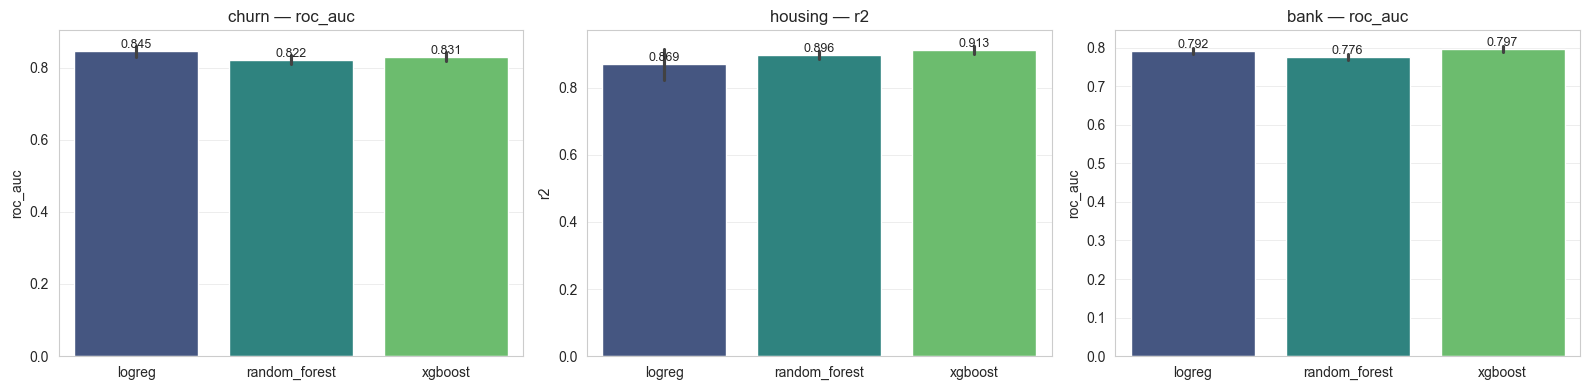

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import FIGURES_DIR

sns.set_style("whitegrid")

# Pick the "main" metric per task
main_metric = {"churn": "roc_auc", "housing": "r2", "bank": "roc_auc"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (ds_name, _) in zip(axes, datasets.items()):
    metric = main_metric[ds_name]
    subset = df_results[(df_results["dataset"] == ds_name) & (df_results["metric"] == metric)]
    sns.barplot(data=subset, x="model", y="value", ax=ax,
                errorbar="sd", palette="viridis")
    ax.set_title(f"{ds_name} — {metric}")
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    # Annotate bars with values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_baseline_results.png", bbox_inches="tight")
plt.show()